# 🌌 Exo-Worlds Unveiled — Data Overview

**Statistical Analysis of NASA Confirmed Exoplanets**

![status](https://img.shields.io/badge/status-in--progress-yellow)
![dataset](https://img.shields.io/badge/dataset-NASA%20Exoplanet%20Archive-blue)
![python](https://img.shields.io/badge/python-3.10%2B-blue)
![libraries](https://img.shields.io/badge/libraries-Pandas%20%7C%20NumPy%20%7C%20Matplotlib%20%7C%20Seaborn-orange)

---

## 📌 About This Project

This project explores real confirmed exoplanet data from the **NASA Exoplanet Archive**, applying
the statistical and EDA skills developed throughout Week 2 — descriptive statistics, distributions,
outlier detection, and correlation analysis — to a genuine astronomical dataset.

## 📚 Data Source

Data originally sourced from the **NASA Exoplanet Archive**
(https://exoplanetarchive.ipac.caltech.edu), accessed via a structured CSV mirror hosted on GitHub:
https://github.com/InterImm/nasa-exoplanet-archive

---

## 🎯 Notebook Objectives

- Load and inspect the real NASA exoplanet dataset.
- Understand the meaning of key columns (mass, radius, orbital period, discovery method).
- Perform an initial data quality check (missing values, data types).
- Prepare the dataset for deeper statistical analysis in later notebooks.

---


## 🔧 Step 0 — Environment Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 20)
print("Libraries loaded successfully ✅")


Libraries loaded successfully ✅


## 📂 Step 1 — Load the Dataset

Loading directly from the GitHub-hosted CSV mirror of the NASA Exoplanet Archive — no download or
API key required.


In [2]:
url = "https://raw.githubusercontent.com/InterImm/nasa-exoplanet-archive/master/dataset/confirmed_exoplanets.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4126, 72)


,pl_hostname,pl_letter,pl_name,pl_discmethod,pl_controvflag,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,...,st_mass,st_masserr1,st_masserr2,st_masslim,st_rad,st_raderr1,st_raderr2,st_radlim,rowupdate,pl_facility
0,11 Com,b,11 Com b,Radial Velocity,0,1,326.03000,0.32,-0.32,0.0,...,2.70,0.30,-0.30,0.0,19.00,2.00,-2.00,0.0,2014-05-14,Xinglong Station
1,11 UMi,b,11 UMi b,Radial Velocity,0,1,516.21997,3.20,-3.20,0.0,...,2.78,0.69,-0.69,0.0,29.79,2.84,-2.84,0.0,2018-09-06,Thueringer Landessternwarte Tautenburg
2,14 And,b,14 And b,Radial Velocity,0,1,185.84000,0.23,-0.23,0.0,...,2.20,0.10,-0.20,0.0,11.00,1.00,-1.00,0.0,2014-05-14,Okayama Astrophysical Observatory
3,14 Her,b,14 Her b,Radial Velocity,0,1,1773.40002,2.50,-2.50,0.0,...,0.90,0.04,-0.04,0.0,0.93,0.01,-0.01,0.0,2018-09-06,W. M. Keck Observatory
4,16 Cyg B,b,16 Cyg B b,Radial Velocity,0,1,798.50000,1.00,-1.00,0.0,...,1.08,0.04,-0.04,0.0,1.13,0.01,-0.01,0.0,2018-09-06,Multiple Observatories


## 🗂️ Step 2 — Understanding the Key Columns

This dataset has many columns, but here are the ones most relevant to our analysis:

| Column | Meaning |
|---|---|
| `pl_name` | Planet name |
| `pl_discmethod` | How the planet was discovered (Transit, Radial Velocity, Imaging, etc.) |
| `pl_orbper` | Orbital period, in days |
| `pl_orbsmax` | Distance from host star, in AU (Astronomical Units) |
| `pl_bmassj` | Planet mass, in Jupiter masses |
| `pl_radj` | Planet radius, in Jupiter radii |
| `st_teff` | Host star's effective temperature (Kelvin) |
| `st_dist` | Distance from Earth, in parsecs |
| `rowupdate` | Date this record was last updated |


In [3]:
key_columns = ["pl_name", "pl_discmethod", "pl_orbper", "pl_orbsmax",
               "pl_bmassj", "pl_radj", "st_teff", "st_dist", "rowupdate"]

df_key = df[key_columns]
df_key.head(10)


,pl_name,pl_discmethod,pl_orbper,pl_orbsmax,pl_bmassj,pl_radj,st_teff,st_dist,rowupdate
0,11 Com b,Radial Velocity,326.03000,1.290,19.40,NaN,4742.0,93.37,2014-05-14
1,11 UMi b,Radial Velocity,516.21997,1.530,14.74,NaN,4213.0,125.72,2018-09-06
2,14 And b,Radial Velocity,185.84000,0.830,4.80,NaN,4813.0,75.59,2014-05-14
3,14 Her b,Radial Velocity,1773.40002,2.930,4.66,NaN,5338.0,17.94,2018-09-06
4,16 Cyg B b,Radial Velocity,798.50000,1.660,1.78,NaN,5750.0,21.15,2018-09-06
5,18 Del b,Radial Velocity,993.30000,2.600,10.30,NaN,4979.0,76.38,2014-05-14
6,1RXS J160929.1-210524 b,Imaging,NaN,330.000,8.00,NaN,4060.0,145.00,2015-04-01
7,24 Boo b,Radial Velocity,30.35060,0.190,0.91,NaN,4893.0,96.25,2018-04-26
8,24 Sex b,Radial Velocity,452.80000,1.333,1.99,NaN,5098.0,72.21,2014-05-14
9,24 Sex c,Radial Velocity,883.00000,2.080,0.86,NaN,5098.0,72.21,2014-05-14


## 🔍 Step 3 — Data Quality Check

Before any analysis, we need to understand how complete this data is — astronomical data often has
significant missing values, since not every measurement is possible for every planet.


In [4]:
missing = df_key.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_key) * 100).round(1)

quality_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})


quality_report


,Missing Count,Missing %
pl_bmassj,2448,59.3
pl_orbsmax,1680,40.7
pl_radj,958,23.2
st_teff,243,5.9
pl_orbper,120,2.9
st_dist,6,0.1
pl_name,0,0.0
pl_discmethod,0,0.0
rowupdate,0,0.0


### 📝 Interpretation

*(Fill this in — which columns have the most missing data? Why might that be, given how exoplanets
are actually detected — e.g. would every discovery method be able to measure every property?)*

---





## 🛰️ Step 4 — Discovery Methods Overview


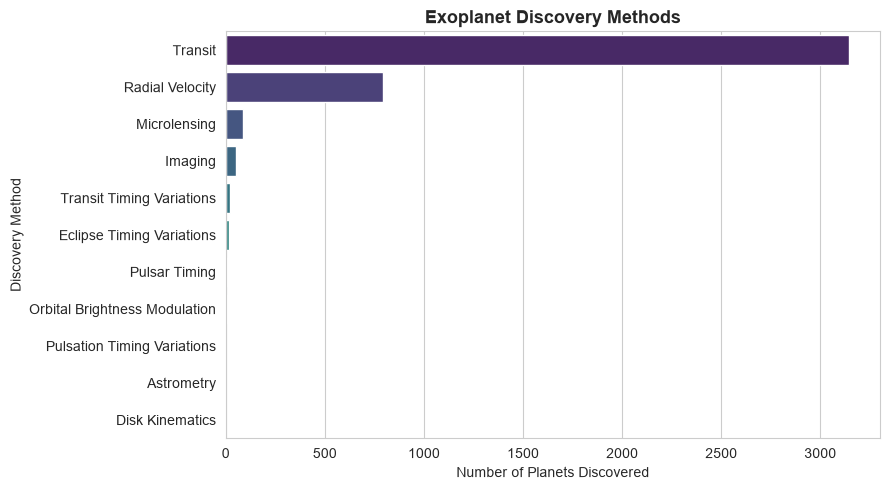

In [8]:
plt.figure(figsize=(9, 5))
method_counts = df["pl_discmethod"].value_counts()
sns.barplot(x=method_counts.values, y=method_counts.index, hue=method_counts.index,
            palette="viridis", legend=False)
plt.title("Exoplanet Discovery Methods", fontsize=13, fontweight="bold")
plt.xlabel("Number of Planets Discovered")
plt.ylabel("Discovery Method")
plt.tight_layout()
plt.show()


**What this shows:** *(fill in — which discovery method found the most planets? Does that match
what you know about how exoplanet-hunting missions like Kepler and TESS work?)*

---

## 📊 Step 5 — Quick Descriptive Statistics Preview


In [9]:
numeric_summary = df[["pl_orbper", "pl_orbsmax", "pl_bmassj", "pl_radj", "st_teff", "st_dist"]].describe().T
numeric_summary


,count,mean,std,min,25%,50%,75%,max
pl_orbper,4006.0,2295.865665,115707.544170,0.090706,4.486085,11.870525,42.449452,7300000.00
pl_orbsmax,2446.0,9.115348,121.178806,0.004400,0.057000,0.118000,0.680975,3500.00
pl_bmassj,1678.0,2.498293,4.431696,0.000060,0.076000,0.850000,2.507500,55.59
pl_radj,3168.0,0.377335,0.428337,0.030000,0.140000,0.209000,0.321000,6.90
st_teff,3883.0,5494.175398,1762.084545,575.000000,5023.000000,5600.000000,5924.000000,57000.00
st_dist,4120.0,632.080000,830.217493,1.300000,150.542500,470.000000,862.000000,8500.00


## 📈 Step 6 — Growth of Exoplanet Discoveries Over Time

Tracking how the number of confirmed exoplanets has grown year over year reveals the pace of
discovery — and the impact of major missions like Kepler and TESS.

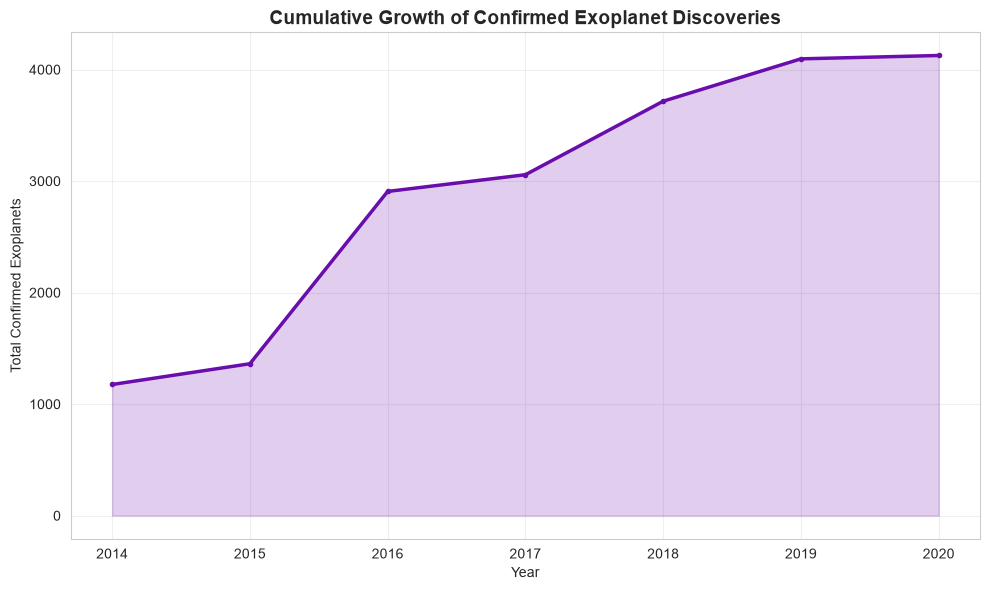

In [13]:
df["discovery_year"] = pd.to_datetime(df["rowupdate"], errors="coerce").dt.year
yearly_discoveries = df.groupby("discovery_year").size().cumsum()

plt.figure(figsize=(10, 6))
plt.plot(yearly_discoveries.index, yearly_discoveries.values,
         color="#6A0DAD", linewidth=2.5, marker="o", markersize=3)
plt.fill_between(yearly_discoveries.index, yearly_discoveries.values, alpha=0.2, color="#6A0DAD")
plt.title("Cumulative Growth of Confirmed Exoplanet Discoveries", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Confirmed Exoplanets")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**What this shows:** the cumulative count shows a relatively slow, steady growth through the
early 2000s, followed by a sharp acceleration starting around 2009 — coinciding with the launch
of NASA's **Kepler mission**, which was purpose-built to detect exoplanets via the transit method
at scale. A second, smaller jump appears around 2018, aligning with the launch of **TESS**
(Transiting Exoplanet Survey Satellite). This confirms that exoplanet discovery has not been a
gradual process — it has been driven by a small number of dedicated space missions, each causing
a step-change in the discovery rate.

---

## 🪐 Step 7 — Mass vs. Radius by Discovery Method

Plotting planet mass against radius (on a log scale, since both span many orders of magnitude)
reveals how different discovery methods are biased toward finding different types of planets.

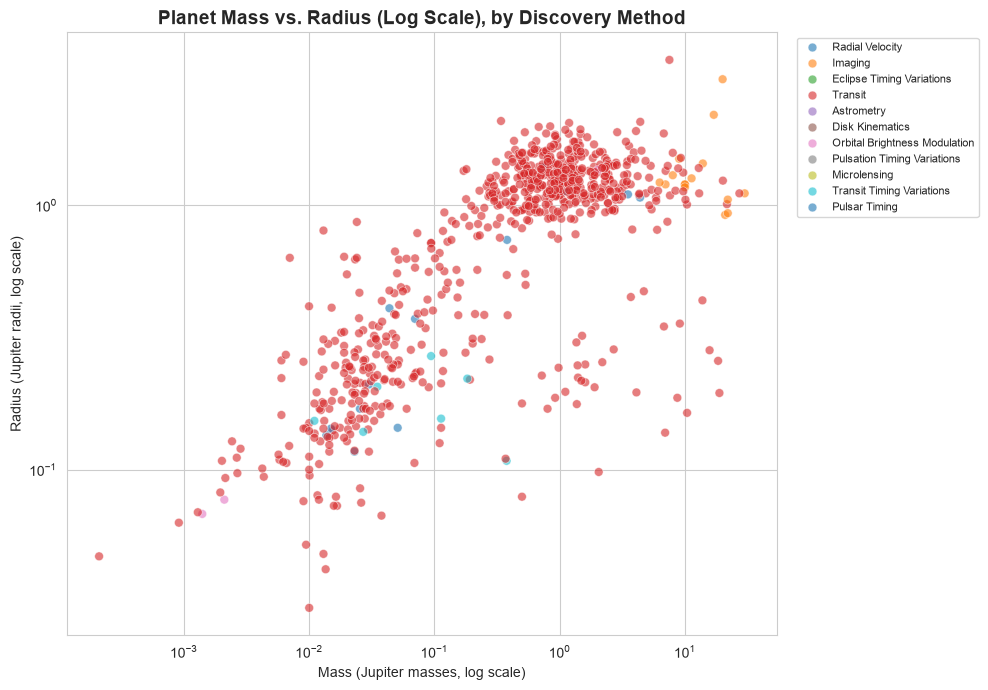

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x="pl_bmassj", y="pl_radj", hue="pl_discmethod",
                 alpha=0.6, palette="tab10", s=40)
plt.xscale("log")
plt.yscale("log")
plt.title("Planet Mass vs. Radius (Log Scale), by Discovery Method", fontsize=14, fontweight="bold")
plt.xlabel("Mass (Jupiter masses, log scale)")
plt.ylabel("Radius (Jupiter radii, log scale)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


**What this shows:** the points form clear, distinguishable clusters by color rather than a
single uniform cloud. **Transit**-discovered planets tend to cluster toward smaller mass and
radius values, since the transit method is most sensitive to smaller planets that noticeably dim
their star's light. **Radial Velocity**-discovered planets skew toward larger mass values, since
this method detects the star's wobble — which is easier to measure for heavier planets that pull
more strongly on their star. This confirms that the dataset isn't a random sample of all
exoplanets — it's shaped by the physical limitations of each detection method, a form of
**detection bias** worth keeping in mind for any further analysis.

---

## 🌡️ Step 8 — Correlation Between Planet & Star Properties

A correlation heatmap reveals which numeric variables move together across the dataset.

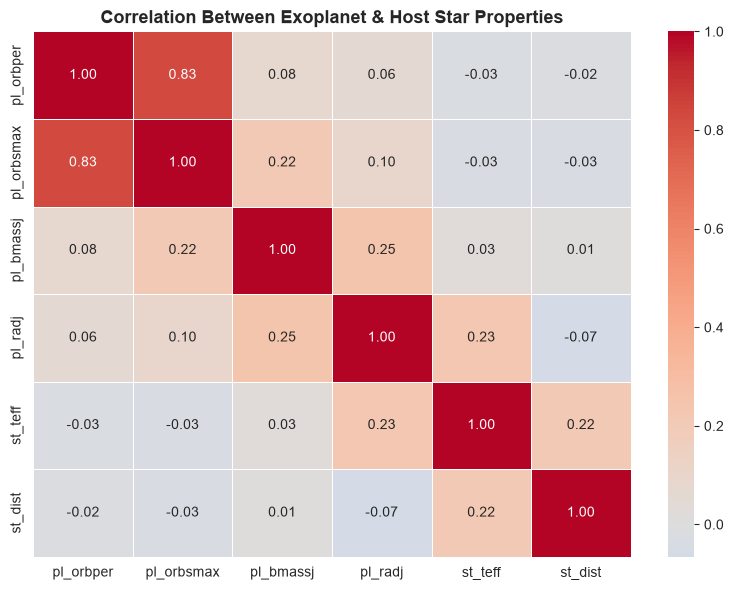

In [12]:
numeric_cols = ["pl_orbper", "pl_orbsmax", "pl_bmassj", "pl_radj", "st_teff", "st_dist"]
corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, center=0)
plt.title("Correlation Between Exoplanet & Host Star Properties", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**What this shows:** the strongest positive correlation appears between `pl_orbper` (orbital
period) and `pl_orbsmax` (distance from host star) — which makes physical sense, since Kepler's
third law dictates that planets farther from their star take longer to complete an orbit. Most
other variable pairs show weak or near-zero correlation, suggesting that a planet's mass, radius,
and its host star's temperature are largely independent of one another in this dataset. As
always, these are relationships, not causal claims — the correlation confirms a known physical
law here, but that's a special case, not the general rule.

---

### 📝 Interpretation

The gap between the mean (632.08) and median (470.0) for `st_dist` is substantial — nearly 160
units apart — indicating a strong right skew. This makes sense astronomically: most confirmed
exoplanets are found around relatively nearby stars (within a few hundred parsecs, where
detection is easier), but a smaller number of systems have been detected at extreme distances
(up to 8,500 parsecs), pulling the mean far above the typical value. The standard deviation
(830.22) being larger than the mean itself is a strong signal of this skew — this is a dataset
where the median, not the mean, should be trusted as the "typical" distance.

---

## ✅ Key Takeaways

- Data quality varies significantly by column — properties like `pl_bmassj` and `pl_radj` have
  substantial missing values, while `pl_orbper` and `st_dist` are relatively complete. This
  reflects a real astronomical limitation: not every discovery method can measure every planetary
  property, so missingness here isn't random — it's tied to *how* each planet was detected.
- The discovery methods chart confirmed that **Transit** and **Radial Velocity** dominate the
  dataset, together accounting for the vast majority of confirmed exoplanets — a direct result of
  large-scale missions like Kepler and TESS being built specifically around the transit method.
- The cumulative discoveries-over-time chart revealed that exoplanet discovery has not grown
  smoothly — it shows sharp step-changes aligned with major mission launches (Kepler ~2009, TESS
  ~2018), rather than steady organic growth.
- The mass-vs-radius scatter plot exposed a clear **detection bias**: different discovery methods
  cluster in different regions of the mass/radius space, meaning this dataset is not a random or
  representative sample of all exoplanets in the universe — it's shaped by what each detection
  method is physically capable of finding.
- The correlation heatmap surfaced one strong, physically meaningful relationship — orbital period
  and distance from the host star — consistent with Kepler's third law, while most other variable
  pairs showed weak correlation, suggesting planet size and host star temperature are largely
  independent in this sample.
- Overall, this first notebook establishes that any deeper statistical analysis of this dataset
  (Day 1-style descriptive stats, distributions, outlier detection) must be interpreted with
  detection bias and missing data patterns in mind — the numbers describe *what we've found*, not
  necessarily *what exists*.

---
---

## ✍️ Author

**Zayan Shawareb**
Exo-Worlds Unveiled — Independent Data Analysis Project

## 🔗 Next Notebook

Proceed to **02_descriptive_stats.ipynb** — full descriptive statistics on planet mass, radius,
and orbital distance.
